# 01. Продажи, маржинальность и категории

за счёт чего растёт оборот и где бизнес зарабатывает.

```
GMV = orders x AOV
orders = active customers x frequency
margin = GMV x take rate
```


In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.db import get_engine, query, save_mart
from src import viz

viz.setup()
engine = get_engine()

## 1. Верхнеуровневые метрики по месяцам

In [2]:
created = viz.add_time_parts(query(engine, "sales_created_daily.sql"), "dt")
paid = viz.add_time_parts(query(engine, "sales_paid_daily.sql"), "dt")

monthly = (
    created.groupby("month", as_index=False)
    .agg(
        gmv_created=("gmv_created", "sum"),
        orders_created=("orders_created", "sum"),
        customers=("customers_created", "sum"),
    )
)
monthly["aov"] = monthly.gmv_created / monthly.orders_created
monthly = viz.add_growth(monthly, ["gmv_created", "orders_created", "aov"], "mom")
monthly.tail()

,month,gmv_created,orders_created,customers,aov,gmv_created_mom,orders_created_mom,aov_mom
14,2018-03-01,951426.19,7000,6937,135.918027,15.375790,7.263255,7.563201
15,2018-04-01,981490.70,6810,6784,144.124919,3.159941,-2.714286,6.038119
16,2018-05-01,978876.09,6747,6725,145.083161,-0.266392,-0.925110,0.664869
17,2018-06-01,859495.57,6105,6088,140.785515,-12.195672,-9.515340,-2.962195
18,2018-07-01,333396.68,2318,2313,143.829456,-61.210192,-62.031122,2.162113


Прирост считается через `pct_change`

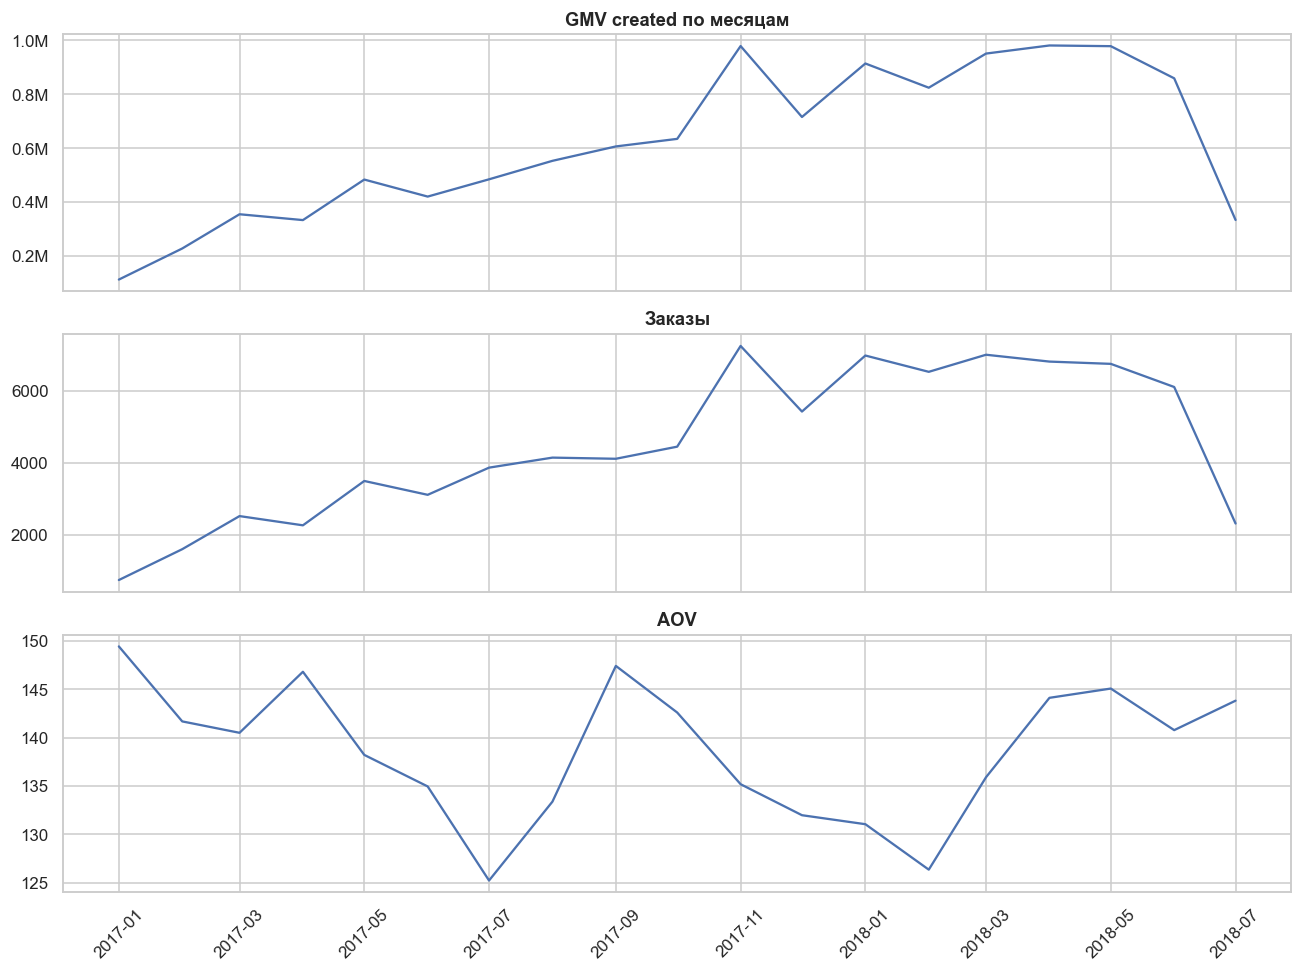

In [3]:
fig, ax = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

ax[0].plot(monthly.month, monthly.gmv_created)
ax[0].set_title("GMV created по месяцам")
viz.money_axis(ax[0])

ax[1].plot(monthly.month, monthly.orders_created)
ax[1].set_title("Заказы")

ax[2].plot(monthly.month, monthly.aov)
ax[2].set_title("AOV")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

GMV в период с 2017-11 вырос за счет увеличения количества заказов

## 2. Недельная динамика и WoW

In [4]:
weekly = (
    created.groupby("week", as_index=False)
    .agg(
        gmv_created=("gmv_created", "sum"),
        orders_created=("orders_created", "sum"),
        customers=("customers_created", "sum"),
    )
)
weekly["aov"] = weekly.gmv_created / weekly.orders_created
weekly = viz.add_growth(weekly, ["gmv_created", "orders_created", "aov", "customers"], "wow")
weekly.tail(6).round(1)

,week,gmv_created,orders_created,customers,aov,gmv_created_wow,orders_created_wow,aov_wow,customers_wow
74,2018-06-04,202515.8,1420,1414,142.6,11.1,32.0,-15.8,31.9
75,2018-06-11,219405.8,1501,1499,146.2,8.3,5.7,2.5,6.0
76,2018-06-18,191037.8,1442,1439,132.5,-12.9,-3.9,-9.4,-4.0
77,2018-06-25,185096.3,1388,1385,133.4,-3.1,-3.7,0.7,-3.8
78,2018-07-02,154628.3,1182,1179,130.8,-16.5,-14.8,-1.9,-14.9
79,2018-07-09,154399.0,975,973,158.4,-0.1,-17.5,21.1,-17.5


## 3. Сезонность по дням недели

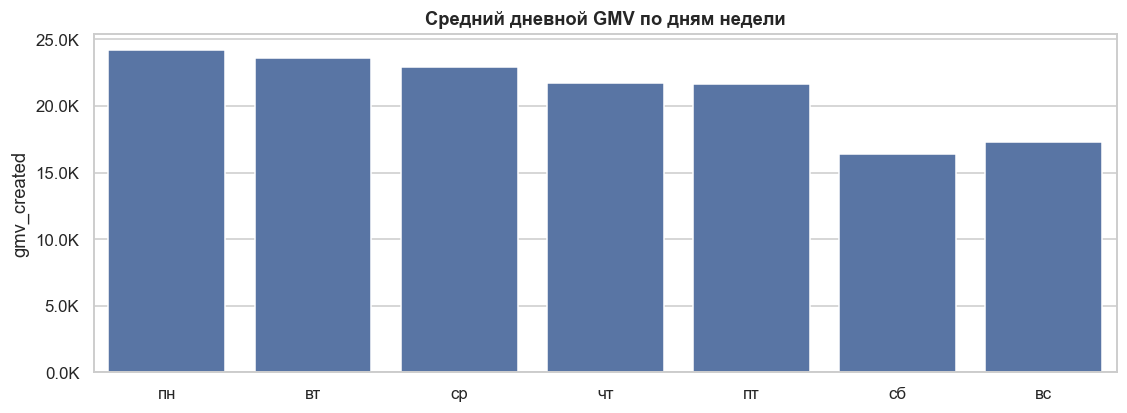

In [5]:
created["weekday"] = created.dt.dt.dayofweek
wd = created.groupby("weekday", as_index=False).gmv_created.mean()
wd["name"] = ["пн", "вт", "ср", "чт", "пт", "сб", "вс"]

sns.barplot(data=wd, x="name", y="gmv_created")
plt.title("Средний дневной GMV по дням недели")
viz.money_axis(unit="K")
plt.xlabel("")
plt.show()

## 4. Маржа и take rate

In [6]:
margin_monthly = (
    paid.groupby("month", as_index=False)
    .agg(gmv_paid=("gmv_paid", "sum"), margin=("margin_paid", "sum"))
)
margin_monthly["take_rate"] = margin_monthly.margin / margin_monthly.gmv_paid * 100
margin_monthly = viz.add_growth(margin_monthly, ["gmv_paid", "margin"], "mom")
margin_monthly.tail().round(2)

,month,gmv_paid,margin,take_rate,gmv_paid_mom,margin_mom
14,2018-03-01,955820.02,243570.63,25.48,18.04,19.80
15,2018-04-01,1001468.98,256819.14,25.64,4.78,5.44
16,2018-05-01,993582.31,261785.69,26.35,-0.79,1.93
17,2018-06-01,869576.34,224859.40,25.86,-12.48,-14.11
18,2018-07-01,286455.15,74758.62,26.10,-67.06,-66.75


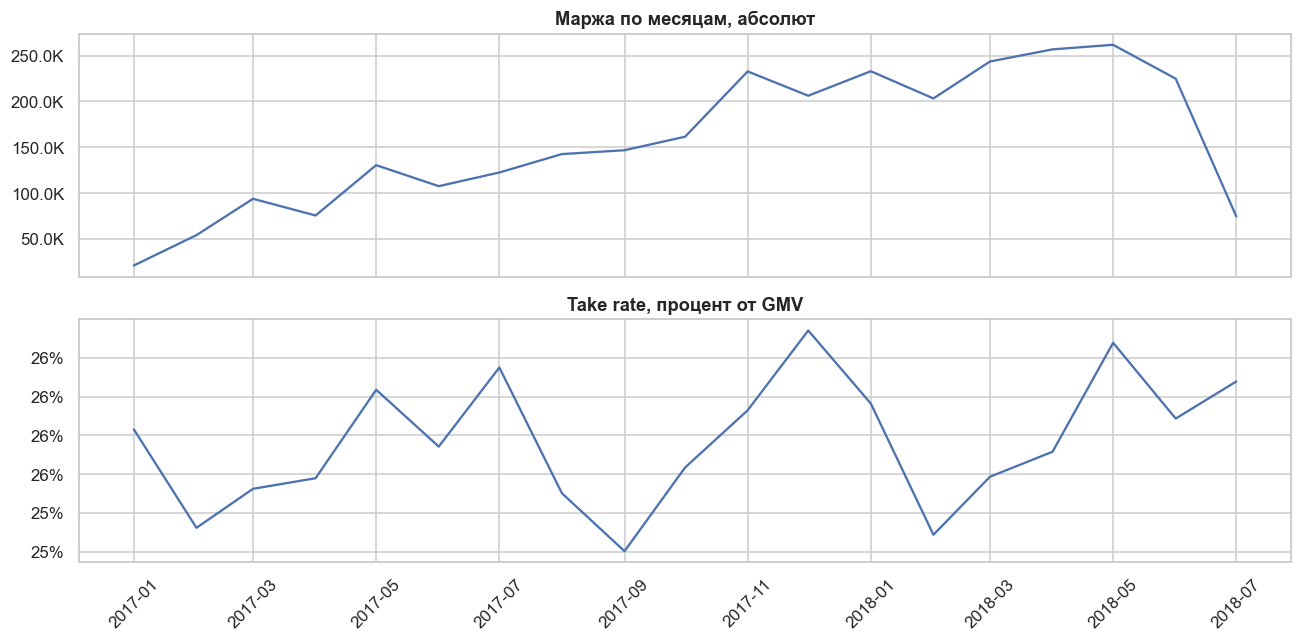

In [7]:
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax[0].plot(margin_monthly.month, margin_monthly.margin)
ax[0].set_title("Маржа по месяцам, абсолют")
viz.money_axis(ax[0], unit="K")

ax[1].plot(margin_monthly.month, margin_monthly.take_rate)
ax[1].set_title("Take rate, процент от GMV")
viz.pct_axis(ax[1])

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Категории: концентрация оборота

In [8]:
cat = viz.add_time_parts(query(engine, "category_daily.sql"), "dt")

cat_total = (
    cat.groupby("category_name", as_index=False)
    .agg(gmv=("gmv_created", "sum"), margin=("margin_created", "sum"))
    .sort_values("gmv", ascending=False)
)
cat_total["take_rate"] = cat_total.margin / cat_total.gmv * 100
cat_total["share"] = cat_total.gmv / cat_total.gmv.sum() * 100
cat_total["cum_share"] = cat_total.share.cumsum()
cat_total.round(1)

,category_name,gmv,margin,take_rate,share,cum_share
6,Home & Garden,3267669.1,816917.3,25.0,27.8,27.8
10,Toys & Entertainment,2177106.7,653132.0,30.0,18.5,46.3
2,Electronics & Computers,1677037.0,218014.8,13.0,14.3,60.6
5,Health & Beauty,1411311.5,324601.6,23.0,12.0,72.6
3,Fashion & Accessories,1374695.3,522384.2,38.0,11.7,84.3
0,Automotive & Industrial,825262.9,222821.0,27.0,7.0,91.4
1,Baby Products,370232.2,103665.0,28.0,3.2,94.5
8,Small Appliances,217023.4,39064.2,18.0,1.8,96.4
9,Stationery & Office Supplies,200110.2,64035.3,32.0,1.7,98.1
7,Pet Supplies,174816.4,47200.4,27.0,1.5,99.5


5 категорий из 11 дают 80% оборота


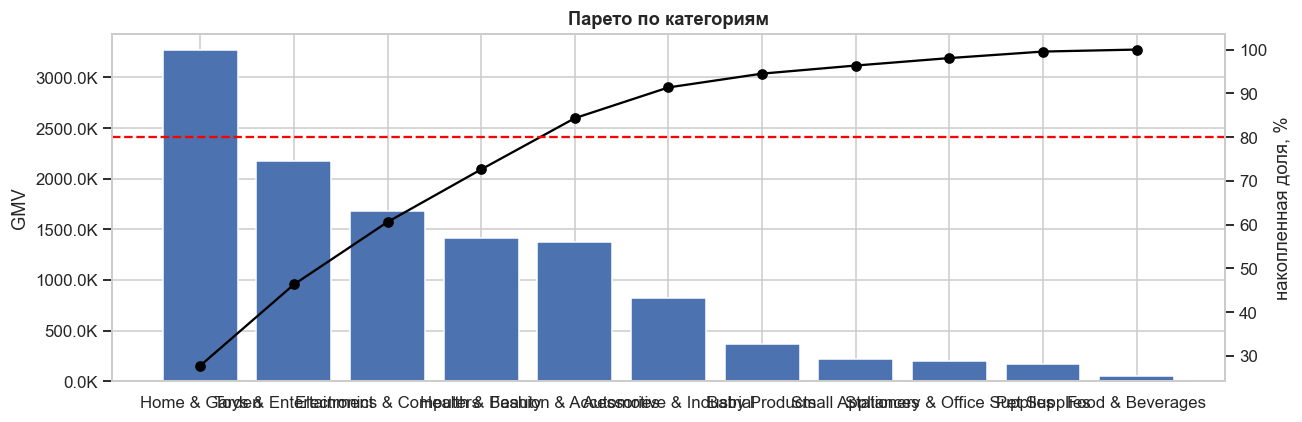

In [9]:
n80 = (cat_total.cum_share <= 80).sum() + 1
print(f"{n80} категорий из {len(cat_total)} дают 80% оборота")

fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.bar(cat_total.category_name, cat_total.gmv)
viz.money_axis(ax1, unit="K")
ax1.set_ylabel("GMV")
ax2 = ax1.twinx()
ax2.plot(cat_total.category_name, cat_total.cum_share, color="black", marker="o")
ax2.axhline(80, color="red", linestyle="--")
ax2.set_ylabel("накопленная доля, %")
ax2.grid(False)
plt.xticks(rotation=60, ha="right")
plt.title("Парето по категориям")
plt.tight_layout()
plt.show()

## 6. Оборот против маржинальности

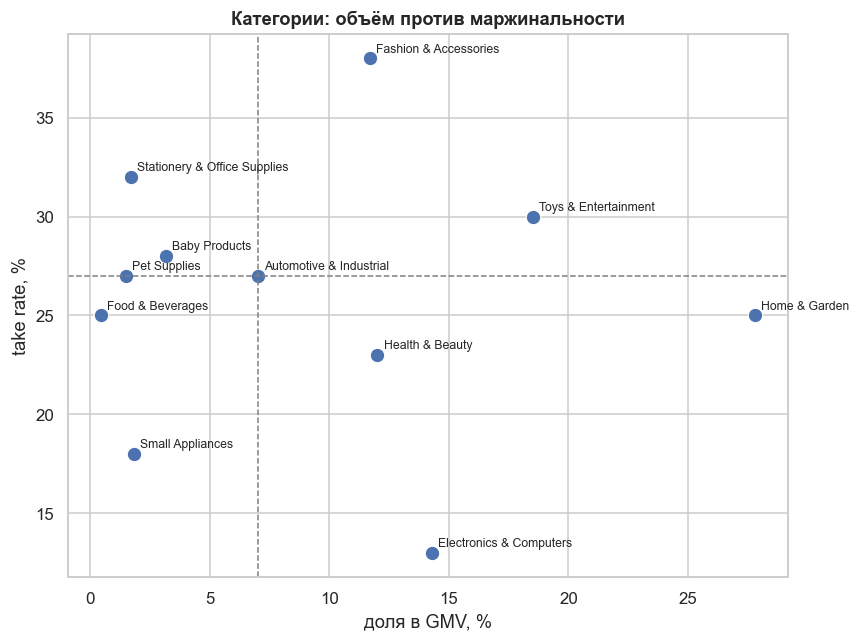

In [10]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=cat_total, x="share", y="take_rate", s=90)
for _, r in cat_total.iterrows():
    plt.annotate(r.category_name, (r.share, r.take_rate), fontsize=8,
                 xytext=(4, 4), textcoords="offset points")
plt.axvline(cat_total.share.median(), color="grey", linestyle="--", lw=1)
plt.axhline(cat_total.take_rate.median(), color="grey", linestyle="--", lw=1)
plt.xlabel("доля в GMV, %")
plt.ylabel("take rate, %")
plt.title("Категории: объём против маржинальности")
plt.tight_layout()
plt.show()

## 7. Декомпозиция прироста по категориям

In [11]:
cat_monthly = cat.groupby(["category_name", "month"], as_index=False).gmv_created.sum()
pivot = cat_monthly.pivot(index="category_name", columns="month", values="gmv_created").fillna(0)

m_curr, m_prev = pivot.columns[-2], pivot.columns[-3]

decomp = pd.DataFrame({
    "prev": pivot[m_prev],
    "curr": pivot[m_curr],
})
decomp["delta"] = decomp.curr - decomp.prev
decomp["delta_pct"] = (decomp.curr / decomp.prev - 1) * 100
decomp["contribution_pp"] = decomp.delta / decomp.prev.sum() * 100
decomp = decomp.sort_values("delta")

print(f"сравниваем {m_prev.date()} и {m_curr.date()}")
decomp.round(1)

сравниваем 2018-05-01 и 2018-06-01


,prev,curr,delta,delta_pct,contribution_pp
category_name,,,,,
Home & Garden,293541.6,240429.7,-53111.9,-18.1,-5.4
Toys & Entertainment,153123.6,110231.1,-42892.5,-28.0,-4.4
Fashion & Accessories,141906.5,101724.1,-40182.4,-28.3,-4.1
Electronics & Computers,108508.9,98825.5,-9683.4,-8.9,-1.0
Baby Products,33420.6,31076.1,-2344.5,-7.0,-0.2
Food & Beverages,5288.4,3232.1,-2056.3,-38.9,-0.2
Small Appliances,20782.6,19521.7,-1260.9,-6.1,-0.1
Stationery & Office Supplies,12923.4,12859.1,-64.3,-0.5,-0.0
Pet Supplies,11708.5,19491.8,7783.3,66.5,0.8


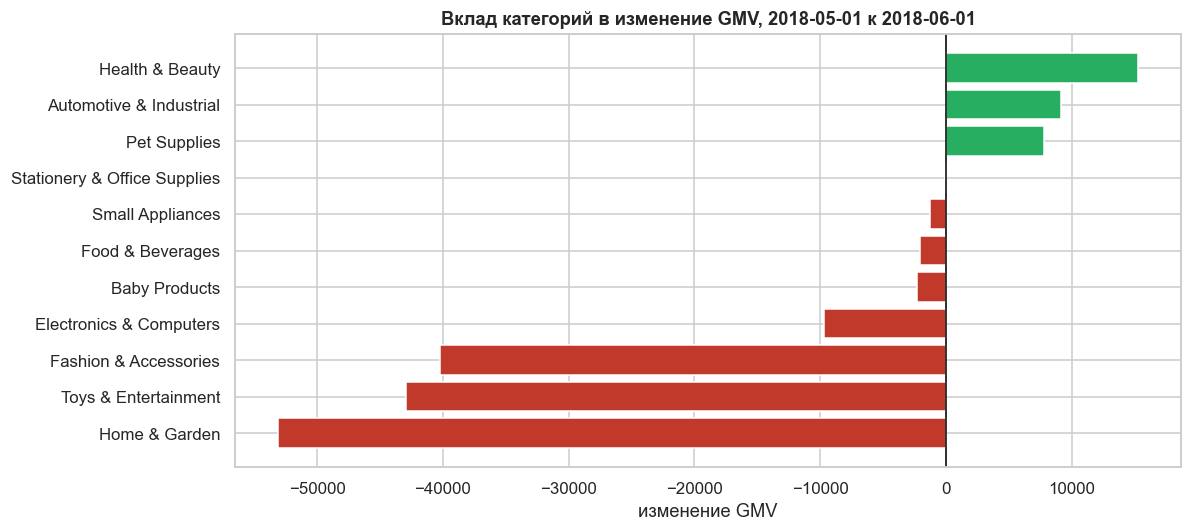

In [12]:
colors = ["#c0392b" if v < 0 else "#27ae60" for v in decomp.delta]
plt.figure(figsize=(11, 5))
plt.barh(decomp.index, decomp.delta, color=colors)
plt.axvline(0, color="black", lw=1)
plt.title(f"Вклад категорий в изменение GMV, {m_prev.date()} к {m_curr.date()}")
plt.xlabel("изменение GMV")
plt.tight_layout()
plt.show()

## 8. Сохраняем витрины для дашборда

In [13]:
save_mart(monthly, "sales_monthly")
save_mart(weekly, "sales_weekly")
save_mart(margin_monthly, "margin_monthly")
save_mart(cat_total, "category_totals")
save_mart(cat_monthly, "category_monthly")

сохранено: data/marts/sales_monthly.csv, строк 19
сохранено: data/marts/sales_weekly.csv, строк 80
сохранено: data/marts/margin_monthly.csv, строк 19
сохранено: data/marts/category_totals.csv, строк 11
сохранено: data/marts/category_monthly.csv, строк 209


PosixPath('/Users/m1/Desktop/marketplace-analytics/data/marts/category_monthly.csv')

## Выводы
1. GMV: май 979 тыс, июнь 859 тыс

2. Take rate держится в коридоре 25.5–26.4% весь последний квартал. Маржа в июне упала на 14.1% при падении оборота на 12.5%, почти пропорционально.

3. 5 категорий из 11 дают 80% оборота. Home & Garden это 27.8% GMV. При этом Electronics & Computers даёт 14.3% оборота, но только 7.2% маржи: take rate 13% против 25–38% у остальных. Обратная ситуация у Fashion & Accessories: 11.7% оборота и 17.3% маржи при take rate 38%.

4. Падение мая к июню объясняется тремя категориями.
Home & Garden (−5.4 п.п.), Toys & Entertainment (−4.4 п.п.) и Fashion & Accessories (−4.1 п.п.) дали вместе −13.9 п.п. из общих −12.2%. Частично компенсировали Health & Beauty (+1.6 п.п.), Automotive & Industrial (+0.9 п.п.) и Pet Supplies (+0.8 п.п., рост на 66.5%).